In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
DATASET_PATH = "../data/Crop_recommendation.csv"          #goes 1 folder ^
df = pd.read_csv(DATASET_PATH)
print("Dataset Shape:", df.shape)
display(df.head())

'''
N          → Nitrogen in soil
P          → Phosphorus in soil
K          → Potassium in soil
temperature → Temperature
humidity    → Humidity
ph          → Soil pH
rainfall    → Rainfall
'''


Dataset Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
print("Missing values:")
print(df.isnull().sum())
print("\nColumns:", df.columns.tolist())          # Column names in the dataset


Missing values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


In [ ]:
X = df[["N","P","K","temperature","humidity","ph","rainfall"]]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))





Training samples: 1760
Testing samples: 440


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("RandomForest model trained successfully.")


Random Forest model trained successfully.


In [ ]:
y_pred = model.predict(X_test)                # predictions of the x_test data is stored in y_pred
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy*100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 99.55 %

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      

out of the 440 test samples , 438 got predicted correctly

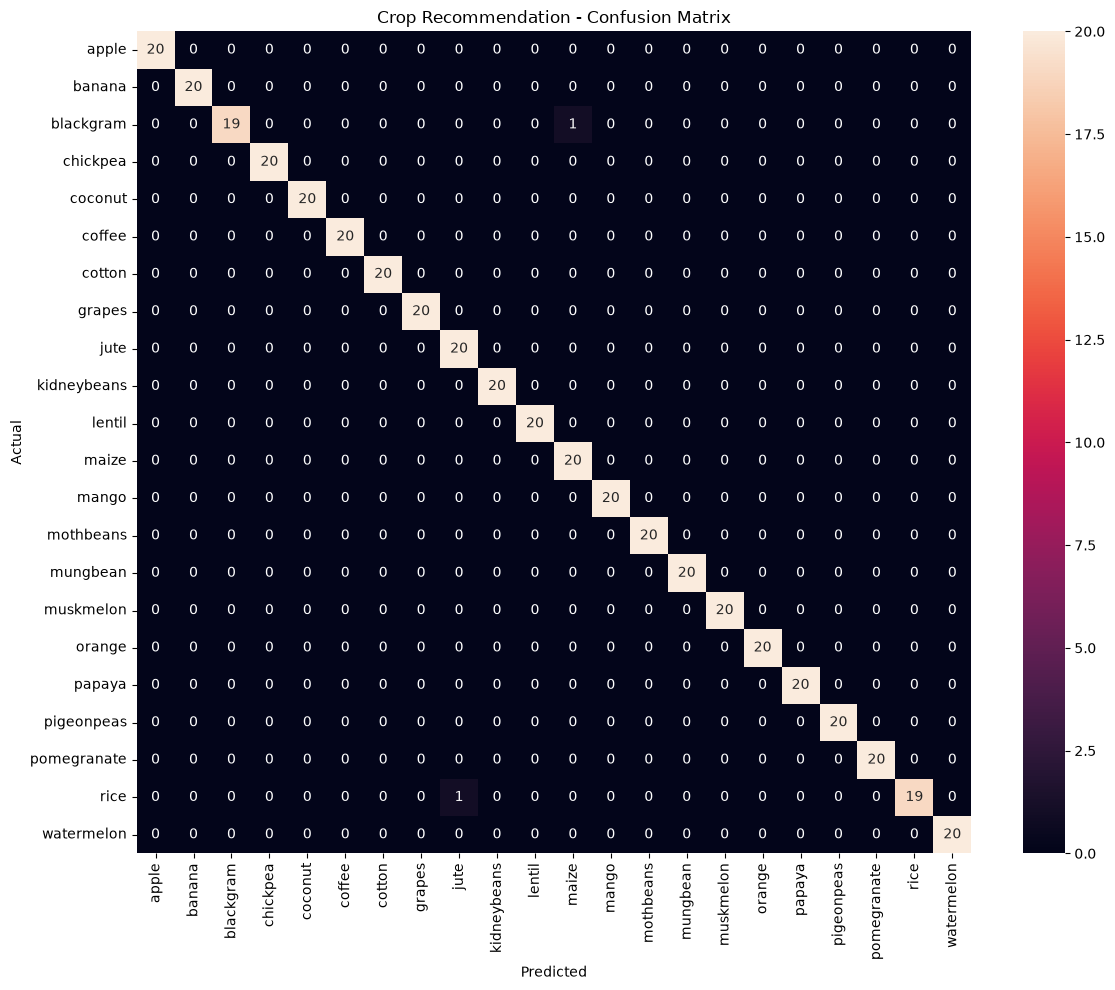

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Crop Recommendation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [8]:
sample = pd.DataFrame([{
    "N": 90, "P": 42, "K": 43,
    "temperature": 25, "humidity": 80,
    "ph": 6.5, "rainfall": 200
}])

prediction = model.predict(sample)[0]
print("Recommended Crop:", prediction)

probs = model.predict_proba(sample)[0]
top = np.argsort(probs)[::-1][:3]
print("\nTop 3 predictions:")
for i in top:
    print(f"{model.classes_[i]}: {probs[i]*100:.2f}%")


Recommended Crop: rice

Top 3 predictions:
rice: 54.00%
jute: 45.00%
watermelon: 1.00%
